In [1]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv("/2017_jun_final.csv")

In [10]:
df.head()

,N,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,...,False,Intermediate (середній),"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,...,False,Pre-intermediate (нище середнього),"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,...,False,Intermediate (середній),"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


In [11]:
print(df.shape)

(8704, 25)


In [12]:
df.dtypes

,0
N,int64
Посада,object
Мова програмування,object
Спеціалізація,object
Загальний досвід роботи,object
Досвід роботи на поточному місці,object
Зарплата на місяць,int64
Зміна зарплати за 12 місяців,int64
Місто,object
Розмір компанії,object


In [13]:
missing = df.isnull().sum() / len(df) * 100

print(missing)

N                                    0.000000
Посада                               0.000000
Мова програмування                  44.232537
Спеціалізація                       82.938879
Загальний досвід роботи              0.000000
Досвід роботи на поточному місці     0.000000
Зарплата на місяць                   0.000000
Зміна зарплати за 12 місяців         0.000000
Місто                                0.000000
Розмір компанії                      0.000000
Тип компанії                         0.000000
Стать                                0.000000
Вік                                  0.000000
Освіта                               0.000000
Університет                          4.113051
Ще студент                           0.000000
Рівень англійської                   0.000000
Предметна область                    2.562040
Дата заповнення                      0.000000
User.Agent                           0.000000
exp                                  0.000000
current_job_exp                   

In [15]:
cols = []
for col in df.columns:
    if df[col].isnull().sum() == 0 or col == "Мова програмування":
        cols.append(col)
df = df[cols]

In [16]:
missing = df.isnull().sum() / len(df) * 100

print(missing)

N                                    0.000000
Посада                               0.000000
Мова програмування                  44.232537
Загальний досвід роботи              0.000000
Досвід роботи на поточному місці     0.000000
Зарплата на місяць                   0.000000
Зміна зарплати за 12 місяців         0.000000
Місто                                0.000000
Розмір компанії                      0.000000
Тип компанії                         0.000000
Стать                                0.000000
Вік                                  0.000000
Освіта                               0.000000
Ще студент                           0.000000
Рівень англійської                   0.000000
Дата заповнення                      0.000000
User.Agent                           0.000000
exp                                  0.000000
current_job_exp                      0.000000
salary                               0.000000
dtype: float64


In [17]:
df = df.dropna()

In [19]:
print(df.shape)

(4854, 20)


In [21]:
python_data = df[df["Мова програмування"] == "Python"]

In [22]:
print(python_data.shape)

(207, 20)


In [23]:
group = python_data.groupby("Посада")

In [25]:
salary = group["Зарплата на місяць"].agg(["min", "max"])

salary

,min,max
Посада,,
Junior Software Engineer,100,1250
Senior Software Engineer,1300,9200
Software Engineer,500,5400
System Architect,3000,5000
Technical Lead,1425,6200


In [26]:
def fill_avg_salary(row):
    return row["Зарплата на місяць"].mean()

In [27]:
salary["avg"] = group.apply(fill_avg_salary)

salary

/tmp/ipykernel_4778/353944266.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  salary["avg"] = group.apply(fill_avg_salary)


,min,max,avg
Посада,,,
Junior Software Engineer,100,1250,560.841270
Senior Software Engineer,1300,9200,3387.096774
Software Engineer,500,5400,1799.070000
System Architect,3000,5000,4000.000000
Technical Lead,1425,6200,3165.909091


In [28]:
salary["avg"].describe()

,avg
count,5.000000
mean,2582.583427
std,1387.255829
min,560.841270
25%,1799.070000
50%,3165.909091
75%,3387.096774
max,4000.000000


In [31]:
salary.to_csv("salary_by_position.csv")
pd.read_csv("salary_by_position.csv")

,Посада,min,max,avg
0,Junior Software Engineer,100,1250,560.841270
1,Senior Software Engineer,1300,9200,3387.096774
2,Software Engineer,500,5400,1799.070000
3,System Architect,3000,5000,4000.000000
4,Technical Lead,1425,6200,3165.909091


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

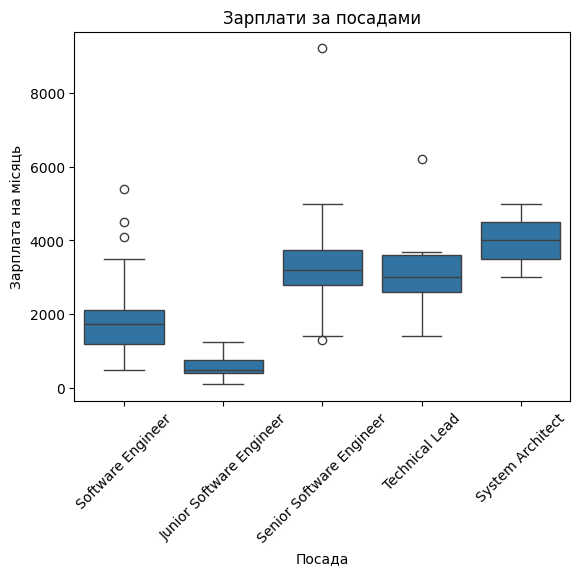

In [36]:
sns.boxplot(x="Посада",y="Зарплата на місяць",data=python_data)
plt.xticks(rotation=45)
plt.title("Зарплати за посадами")
plt.show()

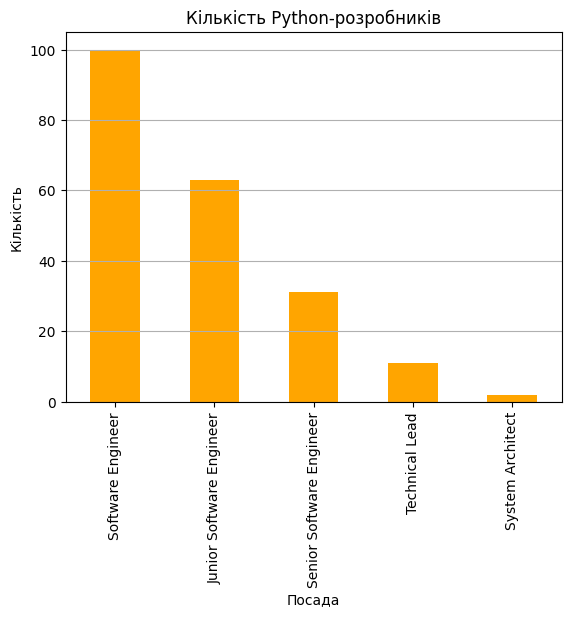

In [38]:
python_data["Посада"].value_counts().plot(kind="bar",color="orange")
plt.title("Кількість Python-розробників")
plt.xlabel("Посада")
plt.ylabel("Кількість")
plt.grid(axis="y")
plt.show()

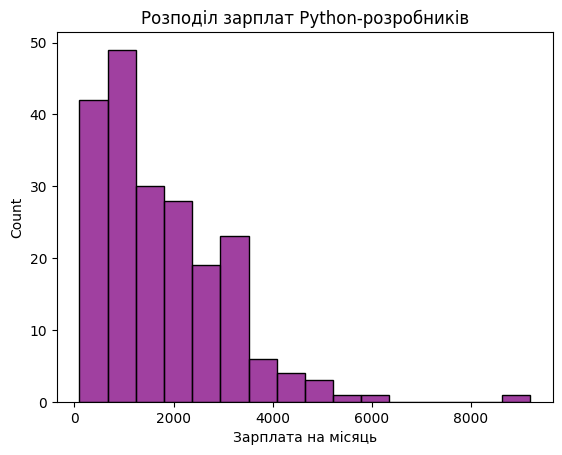

In [42]:
sns.histplot(python_data["Зарплата на місяць"],color="purple")
plt.title("Розподіл зарплат Python-розробників")

plt.show()